# EDA: Kundbortfall på gym (Model Fitness)

**Problem:** Ett gym vill hitta medlemmar som är på väg att säga upp sig, så att personalen kan sätta in åtgärder i tid (t.ex. ett erbjudande eller ett samtal).

**Källa:** Kaggle, Model Fitness Customer Churn https://www.kaggle.com/datasets/ellanihill/model-fitness-customer-churn  
**Licens:** Unknown  
**Obs:** Data är troligen fiktivt.  

Datan hämtas med `kagglehub` och sparas i `data/raw/gym/` (ignoreras av git).

In [1]:
import shutil
from pathlib import Path

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = Path("../data/raw/gym")
RAW_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = RAW_DIR / "model_fitness_churn.csv"

if not CSV_PATH.exists():
    cache = Path(kagglehub.dataset_download("ellanihill/model-fitness-customer-churn"))
    shutil.copy2(next(cache.glob("*.csv")), CSV_PATH)

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip().str.lower()

print(df.shape)
df.info()
df.head()

c:\Projekt Data Science\flotation-silica-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(4000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


## Variabler

| Kolumn | Betydelse |
|---|---|
| `gender` | Kön (0/1) |
| `near_location` | Bor eller arbetar nära gymmet |
| `partner` | Anställd hos ett partnerföretag (rabatt) |
| `promo_friends` | Blev medlem via en väns erbjudande |
| `phone` | Har lämnat telefonnummer |
| `contract_period` | Kontraktslängd i månader (1, 6 eller 12) |
| `group_visits` | Deltar i gruppträning |
| `age` | Ålder |
| `avg_additional_charges_total` | Genomsnittliga extraköp (café, PT, massage m.m.) |
| `month_to_end_contract` | Månader kvar på kontraktet |
| `lifetime` | Månader sedan första besöket |
| `avg_class_frequency_total` | Genomsnittliga besök per vecka under hela medlemskapet |
| `avg_class_frequency_current_month` | Genomsnittliga besök per vecka senaste månaden |
| `churn` | Slutade följande månad (1) eller inte (0) |

## Datakvalitet

In [2]:
print("Saknade värden:", df.isna().sum().sum())
print("Dubblerade rader:", df.duplicated().sum())
print(df.describe().round(2).T)

Saknade värden: 0
Dubblerade rader: 0
                                    count    mean    std    min    25%  \
gender                             4000.0    0.51   0.50   0.00   0.00   
near_location                      4000.0    0.85   0.36   0.00   1.00   
partner                            4000.0    0.49   0.50   0.00   0.00   
promo_friends                      4000.0    0.31   0.46   0.00   0.00   
phone                              4000.0    0.90   0.30   0.00   1.00   
contract_period                    4000.0    4.68   4.55   1.00   1.00   
group_visits                       4000.0    0.41   0.49   0.00   0.00   
age                                4000.0   29.18   3.26  18.00  27.00   
avg_additional_charges_total       4000.0  146.94  96.36   0.15  68.87   
month_to_end_contract              4000.0    4.32   4.19   1.00   1.00   
lifetime                           4000.0    3.72   3.75   0.00   1.00   
avg_class_frequency_total          4000.0    1.88   0.97   0.00   1.18   


In [3]:
# Ser värdena rimliga ut?
print("Kontraktslängder:", sorted(df["contract_period"].unique()))
print("Månader kvar på kontraktet:", sorted(df["month_to_end_contract"].unique()))
print("Fler månader kvar än kontraktets längd:",
      (df["month_to_end_contract"] > df["contract_period"]).sum())

Kontraktslängder: [np.int64(1), np.int64(6), np.int64(12)]
Månader kvar på kontraktet: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0)]
Fler månader kvar än kontraktets längd: 0


## Binära variabler: andel som slutar per grupp

               nej (0)  ja (1)
gender           0.265   0.266
near_location    0.397   0.241
partner          0.333   0.194
promo_friends    0.313   0.158
phone            0.267   0.265
group_visits     0.330   0.173


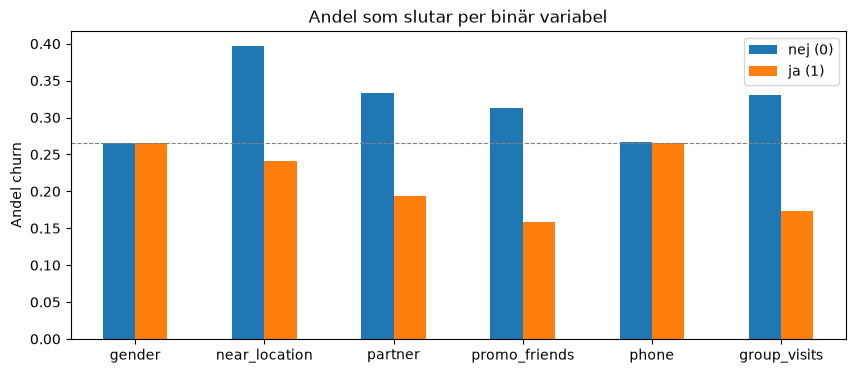

In [4]:
binary_cols = ["gender", "near_location", "partner", "promo_friends", "phone", "group_visits"]

rates = pd.DataFrame({
    col: df.groupby(col)["churn"].mean() for col in binary_cols
}).T.rename(columns={0: "nej (0)", 1: "ja (1)"})
print(rates.round(3))

rates.plot(kind="bar", figsize=(10, 4), title="Andel som slutar per binär variabel")
plt.ylabel("Andel churn")
plt.xticks(rotation=0)
plt.axhline(df["churn"].mean(), color="gray", linestyle="--", linewidth=0.8)
plt.show()

## Numeriska variabler

In [5]:
num_cols = ["contract_period", "age", "avg_additional_charges_total",
            "month_to_end_contract", "lifetime",
            "avg_class_frequency_total", "avg_class_frequency_current_month"]

print(df.groupby("churn")[num_cols].mean().round(2).T)

churn                                   0       1
contract_period                      5.75    1.73
age                                 29.98   26.99
avg_additional_charges_total       158.45  115.08
month_to_end_contract                5.28    1.66
lifetime                             4.71    0.99
avg_class_frequency_total            2.02    1.47
avg_class_frequency_current_month    2.03    1.04


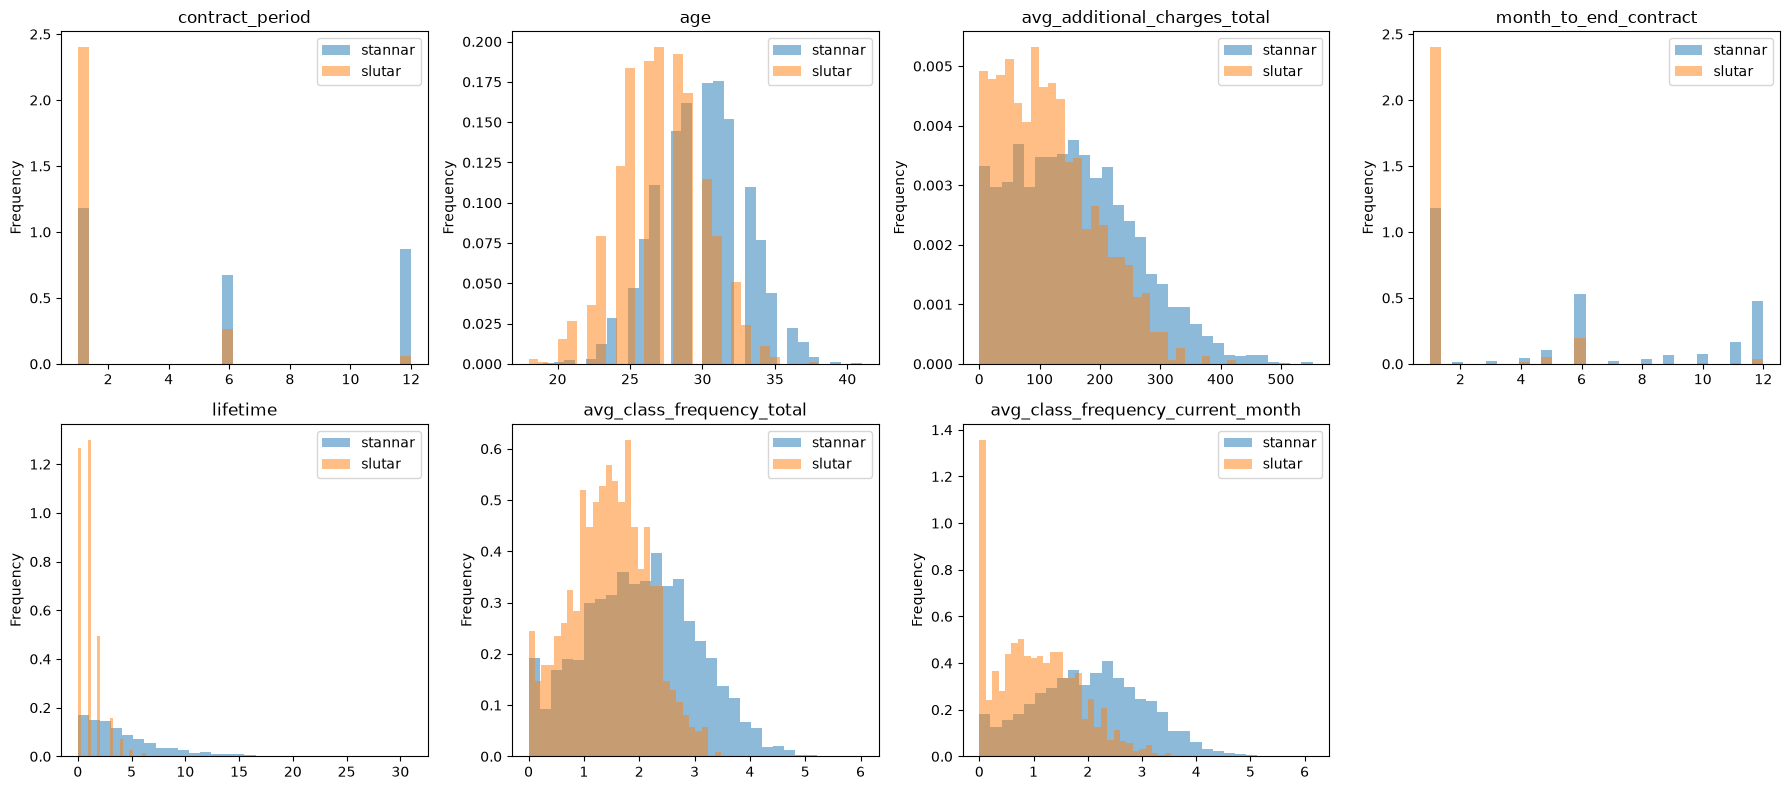

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols):
    for label, group in df.groupby("churn"):
        group[col].plot(kind="hist", bins=30, alpha=0.5, ax=ax, density=True,
                        label="slutar" if label == 1 else "stannar")
    ax.set_title(col)
    ax.legend()
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

## Kontrakt: risk för läckage

Medlemmar med lång tid kvar på kontraktet borde sällan kunna sluta.  
Om churn nästan bara förekommer vid 1 månad kvar avslöjar variabeln svaret.

In [7]:
print("Andel churn per kontraktslängd:")
print(df.groupby("contract_period")["churn"].agg(["mean", "size"]).round(3))

print("\nAndel churn per antal månader kvar:")
print(df.groupby("month_to_end_contract")["churn"].agg(["mean", "size"]).round(3))

Andel churn per kontraktslängd:
                  mean  size
contract_period             
1                0.423  2207
6                0.125   833
12               0.024   960

Andel churn per antal månader kvar:
                        mean  size
month_to_end_contract             
1.0                    0.423  2207
2.0                    0.143    14
3.0                    0.043    23
4.0                    0.121    58
5.0                    0.146   130
6.0                    0.118   645
7.0                    0.040    25
8.0                    0.026    38
9.0                    0.014    73
10.0                   0.024    82
11.0                   0.022   181
12.0                   0.025   524


## Tid som medlem

           mean  size
lifetime             
0         0.828   487
1         0.491   843
2         0.257   610
3         0.102   490
4         0.060   383
5         0.029   273
6         0.018   220
7         0.000   167
8         0.009   111
9         0.010   100
10        0.000    76
11        0.000    48


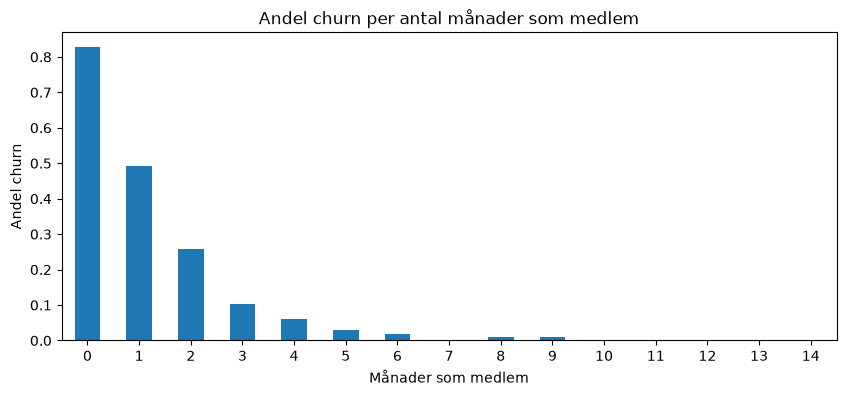

In [8]:
by_lifetime = df.groupby("lifetime")["churn"].agg(["mean", "size"])
print(by_lifetime.head(12).round(3))

by_lifetime["mean"].head(15).plot(kind="bar", figsize=(10, 4),
                                  title="Andel churn per antal månader som medlem")
plt.ylabel("Andel churn")
plt.xlabel("Månader som medlem")
plt.xticks(rotation=0)
plt.show()

## Träningsfrekvens: har aktiviteten minskat?

En minskning den senaste månaden jämfört med snittet borde vara en varningssignal.

        count  mean   std   min   25%   50%   75%   max
churn                                                  
0      2939.0  0.00  0.10 -0.39 -0.06  0.00  0.07  0.38
1      1061.0 -0.43  0.47 -1.86 -0.75 -0.43 -0.12  1.06


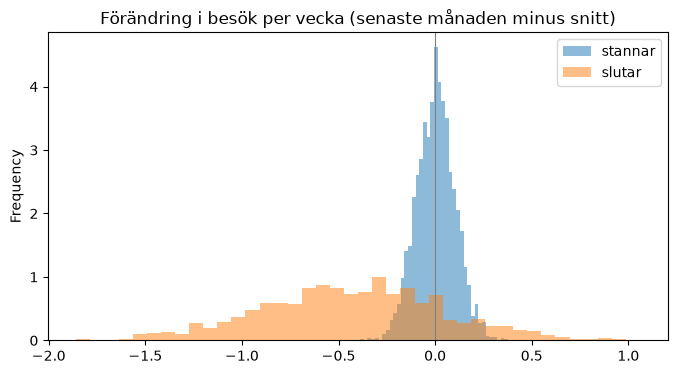

In [9]:
df["freq_change"] = df["avg_class_frequency_current_month"] - df["avg_class_frequency_total"]
print(df.groupby("churn")["freq_change"].describe().round(2))

for label, group in df.groupby("churn"):
    group["freq_change"].plot(kind="hist", bins=40, alpha=0.5, density=True,
                              label="slutar" if label == 1 else "stannar", figsize=(8, 4))
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Förändring i besök per vecka (senaste månaden minus snitt)")
plt.legend()
plt.show()

## Regelbaserad baseline

Förslaget: flagga medlemmar som slutat träna. Datan saknar "dagar sedan senaste besök", så träningsfrekvensen den senaste månaden används som närmevärde.

In [10]:
rows = []
for threshold in [0.5, 1.0, 1.5, 2.0]:
    pred = (df["avg_class_frequency_current_month"] < threshold).astype(int)
    tp = ((pred == 1) & (df["churn"] == 1)).sum()
    rows.append({
        "regel": f"besök/vecka < {threshold}",
        "precision": tp / pred.sum() if pred.sum() else 0,
        "recall": tp / df["churn"].sum(),
        "andel flaggade": pred.mean(),
    })
print(pd.DataFrame(rows).round(2))

               regel  precision  recall  andel flaggade
0  besök/vecka < 0.5       0.58    0.27            0.13
1  besök/vecka < 1.0       0.52    0.51            0.26
2  besök/vecka < 1.5       0.45    0.72            0.42
3  besök/vecka < 2.0       0.40    0.88            0.59


## Samband mellan variablerna

Höga korrelationer mellan indata kan göra koefficienterna i logistisk regression svårtolkade.

In [13]:
corr = df[num_cols + binary_cols + ["churn"]].corr()
print("Starka samband mellan indata (|r| > 0.7):")
pairs = corr.where(lambda c: c.abs() > 0.7).stack().dropna()
print(pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)].round(2))

Starka samband mellan indata (|r| > 0.7):
contract_period                    month_to_end_contract        0.97
avg_class_frequency_current_month  avg_class_frequency_total    0.95
dtype: float64


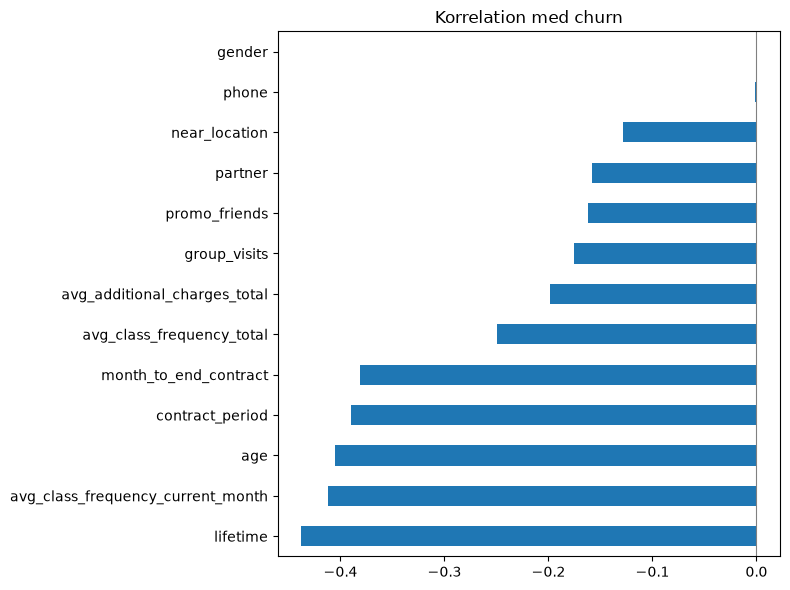

In [14]:
target_corr = corr["churn"].drop("churn").sort_values()
target_corr.plot(kind="barh", figsize=(8, 6), title="Korrelation med churn")
plt.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

## Sammanfattning

- **Datan:** 4 000 medlemmar, 13 variabler, inga saknade värden eller dubbletter. Rimlighetskontroller OK.
- **Målvariabel:** 26,5 % slutar. Att även medlemmar med 12 månader kvar på kontraktet "slutar" tyder på att churn betyder att medlemmen slutade komma, inte att kontraktet sades upp.
- **Starkaste signaler:**
  - Tid som medlem: 83 % slutar första månaden, nästan ingen efter 7 månader.
  - Minskad träning: de som slutar har i snitt minskat med 0,43 besök/vecka senaste månaden, de som stannar med 0,00.
  - Kontraktslängd: 42 % churn vid 1 månad, 2,4 % vid 12 månader.
- **Svaga eller inga signaler:** kön och telefonnummer.
- **Baseline:** Regeln "färre än 1 besök/vecka senaste månaden" flaggar 26 % och fångar 51 % av de som slutar (precision 0,52), dubbelt så bra som slumpen.
- **Starka samband mellan indata:** `contract_period` och `month_to_end_contract` (0,97). Bara en av dem används.
- **Läckagerisk:** `avg_class_frequency_current_month`. Oklart om "current month" är månaden före eller samma som churn, och de som stannar varierar orimligt lite i träning. Modeller jämförs med och utan variabeln.
- **Datan är troligen genererad**, vilket begränsar hur mycket slutsatserna säger om riktiga gym.